# Quality Control of AFM Force Spectroscopy Data with Variational Autoencoders


<a href="https://colab.research.google.com/github/JChonpca/ASAP/blob/QC/tutorial/QC/QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [2]:
# !pip install deeplay  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that trains the variational autoencoder on the AFM force spectroscopy data and uses it to check the good/bad curves in the latent space with the provided label.

## 1. Load the 3T3 Cell Dataset

### 1.1. Download the 3T3 Cell Dataset

Download the `3T3_cell_dataset`. This folder contains AFM force spectroscopy collected using the 3T3 cell. One file corresponds to the approach curves (`approach.pkl`), while the other one is the retraction part (`retraction.pkl`), where curves in the two `.pkl` files are paired. The label file (`label.npy`) is for the approach part only. Inside the label file, `0` is good, `1` is bad, and `-1` is unknown.

In [3]:
import os

if not os.path.exists("3t3_cell_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/3t3_cell_dataset")

### 1.2. Explore the 3T3 Cell Dataset

Load the 3T3 cell dataset ...

In [4]:
import numpy as np

# Define the function to sort the file into the same order
def sort_by_name(filename):
    time_part = filename.split(".")[0]
    return int(time_part)

# Define the function to fetch data and label location
def fetch_curve(location):
    file_list = os.listdir(location)
    file_list = sorted(file_list, key=sort_by_name)
    data_list = [np.load(os.path.join(location, i)) for i in file_list]

    return data_list

# Load the data and label
data_approach = fetch_curve(os.path.join(os.getcwd(), "3t3_cell_dataset", "approach"))
data_retraction = fetch_curve(
    os.path.join(os.getcwd(), "3t3_cell_dataset", "retraction")
)

# Load the label
label_data_dir = os.path.join(os.getcwd(), "3t3_cell_dataset", "label.npy")
label_set = np.load(label_data_dir)


... and print the number of approach/retraction curves and labels.

In [5]:
print(
    f"3T3 cell dataset: {len(data_approach)} approach curves, {len(data_retraction)} retraction curves, and {len(label_set)} labels"
)

3T3 cell dataset: 2548 approach curves, 2548 retraction curves, and 2548 labels


Then, calculate the length of each curve in the dataset ...

In [6]:
# Calculate the sequence length of each curve
data_length_approach = [i.shape[0] for i in data_approach]
data_length_retraction = [i.shape[0] for i in data_retraction]

... and visualize the distribution. The lengths of approach curves are usually shorter than the one set in setup (3000 in these experiments) due to differences in topology across cell parts.

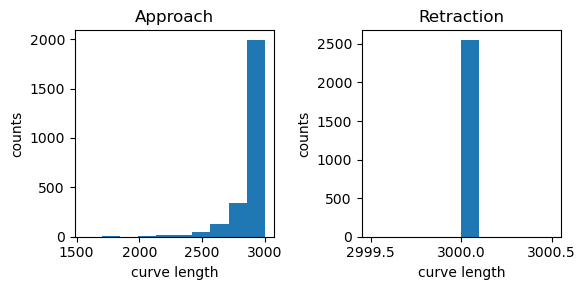

In [7]:
import matplotlib.pyplot as plt

# Plot the length distribution for both the approach and retraction curve
length_list = [data_length_approach, data_length_retraction]
title_list = ["Approach", "Retraction"]
fig, axs = plt.subplots(1, 2, figsize=((6, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_length_plot = length_list[idx]
    ax.hist(data_length_plot)
    ax.set_xlabel("curve length", fontsize=10)
    ax.set_ylabel("counts", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.set_title(title_list[idx])
fig.tight_layout()
plt.show()

Now, we can plot some paired approach/retraction curves.

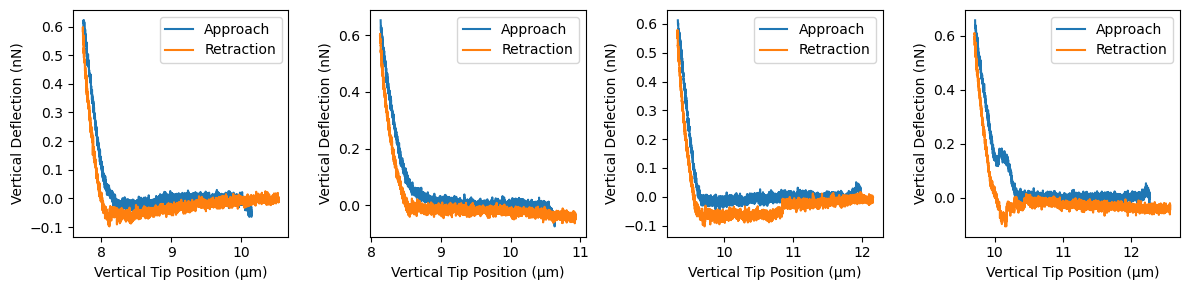

In [8]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_apporach_plot, data_retraction_plot = data_approach[idx], data_retraction[idx]
    ax.plot(data_apporach_plot[:,0], data_apporach_plot[:,1], label=title_list[0])
    ax.plot(data_retraction_plot[:,0], data_retraction_plot[:,1], label=title_list[1])
    ax.set_xlabel("Vertical Tip Position (µm)", fontsize=10)
    ax.set_ylabel("Vertical Deflection (nN)", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.legend()
fig.tight_layout()
plt.show()

## 2. Quality Control of Approach Curves

### 2.1. Data Preprocessing

For approach curves, we downsample each curve to make the length align with the shortest one ...

In [9]:
# downsample the curve to get the same input size for VAE
downsampling_data = []
for indx in range(len(data_approach)):
    sub_indices = np.linspace(0, data_approach[indx].shape[0]-1, min(data_length_approach))
    sub_indices = np.round(sub_indices).astype(int)
    downsampling_data.append(data_approach[indx][sub_indices][:,1])

... and normolized each curve to the range. 

In [10]:
# normalize each curve according to its max and min value
normolized_downsampling_data = []
for i in range(len(downsampling_data)):
    normolized_downsampling_data.append(
        (downsampling_data[i] - downsampling_data[i].min())
        / (downsampling_data[i].max() - downsampling_data[i].min())
    )

Then, we can plot some normalized curves.

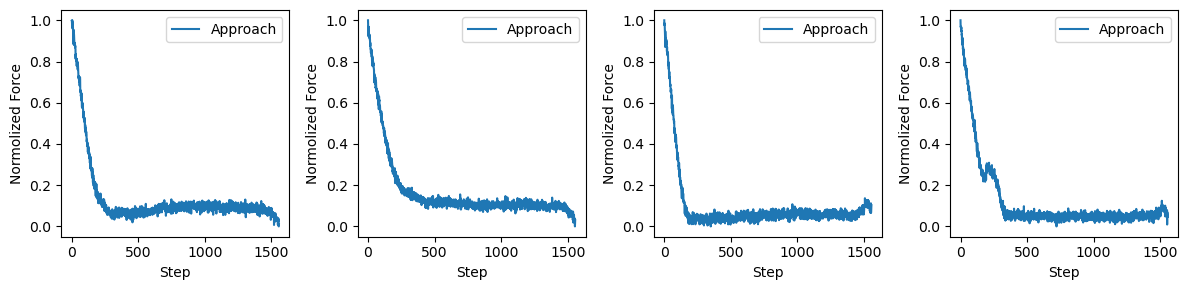

In [11]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_apporach_plot = normolized_downsampling_data[idx]
    ax.plot(data_apporach_plot[::-1], label=title_list[0])
    ax.set_xlabel("Step", fontsize=10)
    ax.set_ylabel("Normolized Force", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.legend()
fig.tight_layout()
plt.show()

### 2.2. Define the Dataloader

Define a custom AFM dataset ...

In [12]:
import torch
import deeplay as dl

class AFMDataset(torch.utils.data.Dataset):
    """Dataset of AFM Force Spectroscopy."""

    def __init__(self, data):
        """Initialize AFM dataset."""
        self.curves = np.array(data)

    def __len__(self):
        """Return number of curves."""
        return self.curves.shape[0]

    def __getitem__(self, idx):
        """Get next curve."""
        curve = torch.tensor(self.curves[idx]).float()
        return [curve, curve]

... and use it to create the train data and test data loaders.

In [13]:
from sklearn.model_selection import train_test_split

# Randomly select the train and test data
train_x, test_x, label_x, label_y = train_test_split(
    normolized_downsampling_data, label_set, test_size=0.2, random_state=577
)

# Randomly select the train and test dataset
train_dataloader = dl.DataLoader(
    AFMDataset(data=train_x),
    batch_size=10240,
)

test_dataloader = dl.DataLoader(
    AFMDataset(data=test_x),
    batch_size=10240,
)

### 2.3. Define the Autoencoders

Define the application module of variational autoencoder based on the multilayer perceptron ...

In [14]:
import lightning as L
import torch
import torch.nn as nn
from typing import Optional, Sequence, Callable, List
from deeplay.applications import Application
from deeplay.external import External, Optimizer, Adam


class MLPVariationalAutoEncoder(Application):

    last_channels: int
    latent_dim: int
    encoder: torch.nn.Module
    decoder: torch.nn.Module
    beta: float
    reconstruction_loss: torch.nn.Module
    metrics: list
    optimizer: Optimizer

    def __init__(
        self,
        last_channels: int,
        encoder: Optional[nn.Module] = None,
        decoder: Optional[nn.Module] = None,
        reconstruction_loss: Optional[Callable] = nn.BCELoss(reduction="sum"),
        latent_dim=int,
        beta=1,
        optimizer=None,
        **kwargs,
    ):
        self.encoder = encoder
        self.fc_mu = nn.Linear(
            last_channels,
            latent_dim,
        )
        self.fc_var = nn.Linear(
            last_channels,
            latent_dim,
        )
        self.fc_dec = nn.Linear(
            latent_dim,
            last_channels,
        )
        self.decoder = decoder
        self.reconstruction_loss = reconstruction_loss or nn.BCELoss(reduction="sum")
        self.latent_dim = latent_dim
        self.beta = beta

        super().__init__(**kwargs)

        self.optimizer = optimizer or Adam(lr=1e-4)

        @self.optimizer.params
        def params(self):
            return self.parameters()

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)

        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z):
        x = self.fc_dec(z)
        x = self.decoder(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = self.train_preprocess(batch)
        y_hat, mu, log_var, z = self(x)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"train_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss

    def test_step(self, batch, batch_idx):

        x, y = self.test_preprocess(batch)
        y_hat, mu, log_var, z = self(x)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"test_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss
        

    def validation_step(self, batch, batch_idx):

        x, y = self.val_preprocess(batch)
        y_hat, mu, log_var, z = self(x)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"val_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss
    
    def compute_loss(self, y_hat, y, mu, log_var):
        rec_loss = self.reconstruction_loss(y_hat, y)
        KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        return rec_loss, KLD

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        y_hat = self.decode(z)
        return y_hat, mu, log_var, z


... use it to instantiation the model.

In [15]:
encoder_block = dl.MultiLayerPerceptron(
    in_features=min(data_length_approach),
    hidden_features=[512, 256, 128, 64],
    out_features=64,
)

encoder_block.blocks[0].activated(nn.Tanh)
encoder_block.blocks[1].activated(nn.Tanh)
encoder_block.blocks[2].activated(nn.Tanh)
encoder_block.blocks[3].activated(nn.Tanh)
encoder_block.blocks[4].activated(nn.Tanh)

decoder_block = dl.MultiLayerPerceptron(
    in_features=64,
    hidden_features=[64, 128, 256, 512],
    out_features=min(data_length_approach),
    out_activation=nn.Sigmoid(),
)

decoder_block.blocks[0].activated(nn.Tanh)
decoder_block.blocks[1].activated(nn.Tanh)
decoder_block.blocks[2].activated(nn.Tanh)
decoder_block.blocks[3].activated(nn.Tanh)
decoder_block.blocks[4].activated(nn.Sigmoid)

vae = MLPVariationalAutoEncoder(
    last_channels=64,
    encoder=encoder_block,
    decoder=decoder_block,
    reconstruction_loss=torch.nn.MSELoss(reduction="sum"),
    beta=1,
    latent_dim=32,
).create()

print(vae)

MLPVariationalAutoEncoder(
  (encoder): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=1557, out_features=512, bias=True)
        (activation): Tanh()
      )
      (1): LinearBlock(
        (layer): Linear(in_features=512, out_features=256, bias=True)
        (activation): Tanh()
      )
      (2): LinearBlock(
        (layer): Linear(in_features=256, out_features=128, bias=True)
        (activation): Tanh()
      )
      (3): LinearBlock(
        (layer): Linear(in_features=128, out_features=64, bias=True)
        (activation): Tanh()
      )
      (4): LinearBlock(
        (layer): Linear(in_features=64, out_features=64, bias=True)
        (activation): Tanh()
      )
    )
  )
  (fc_mu): Linear(in_features=64, out_features=32, bias=True)
  (fc_var): Linear(in_features=64, out_features=32, bias=True)
  (fc_dec): Linear(in_features=32, out_features=64, bias=True)
  (decoder): MultiLayerPerceptron(
    (blocks): LayerList(
  

### 2.4. Train the Autoencoders

Define trainner with the callback function to save the best model by monitoring the validation loss.

In [16]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    monitor="val_total_loss",
    mode="min",
    save_top_k=1
)

vae_trainer = dl.Trainer(max_epochs=10000, accelerator="auto", callbacks=[checkpoint_callback])

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You can also load the trained model from our side.

In [17]:
# Uncomment if you don't want to train

#best_model_path = os.path.join(os.getcwd(), "Model", "3t3_qc", "epoch=5178-step=5179.ckpt")
#print(f"Loading the model from DeepTrack Team at {best_model_path}")
#vae.load_state_dict(torch.load(best_model_path)["state_dict"])
#best_model = vae

Loading the model from DeepTrack Team at /Users/iluvatar/Desktop/Bruker_QC/personalrepo/ASAP/tutorial/QC/Model/3t3_qc/epoch=5178-step=5179.ckpt


Or train the neural network regressor with the AFM force spectroscopy data ...

In [18]:
vae_trainer.fit(vae, train_dataloader, test_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ MultiLayerPerceptron │  974 K │ train │     0 │
│ 1 │ fc_mu               │ Linear               │  2.1 K │ train │     0 │
│ 2 │ fc_var              │ Linear               │  2.1 K │ train │     0 │
│ 3 │ fc_dec              │ Linear               │  2.1 K │ train │     0 │
│ 4 │ decoder             │ MultiLayerPerceptron │  975 K │ train │     0 │
│ 5 │ reconstruction_loss │ MSELoss              │      0 │ train │     0 │
│ 6 │ train_metrics       │ MetricCollection     │      0 │ train │     0 │
│ 7 │ val_metrics         │ MetricCollection     │      0 │ train │     0 │
│ 8 │ test_metrics        │ MetricCollection     │      0 │ train │     0 │
│ 9 │ optimizer           │ Adam                 │      0 │ train │     0 │
└───┴─────────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 2.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.0 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 42                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                            …

/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). 

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


... and load the best model from the callback function.

In [23]:
print(f"The best model is save at {checkpoint_callback.best_model_path}")
best_model = MLPVariationalAutoEncoder.load_from_checkpoint(checkpoint_callback.best_model_path)

The best model is save at /Users/iluvatar/Desktop/Bruker_QC/personalrepo/ASAP/tutorial/QC/lightning_logs/version_2/checkpoints/epoch=69-step=70.ckpt


### 2.5. Evaluate the Best Model

Evaluate the model in both train dataset and test dataset.

In [24]:
print("The performance in Trainset")
_ = vae_trainer.test(best_model, train_dataloader)

The performance in Trainset


/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     2723.46240234375      │
│    test_rec_loss_epoch    │     3393.58544921875      │
│   test_total_loss_epoch   │      6117.0478515625      │
└───────────────────────────┴───────────────────────────┘

In [25]:
print("The performance in Testset")
_ = vae_trainer.test(best_model, test_dataloader)

The performance in Testset


Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     667.5950927734375     │
│    test_rec_loss_epoch    │    1094.7147216796875     │
│   test_total_loss_epoch   │     1762.309814453125     │
└───────────────────────────┴───────────────────────────┘

The best model can used to generate the reconstruction curves too.

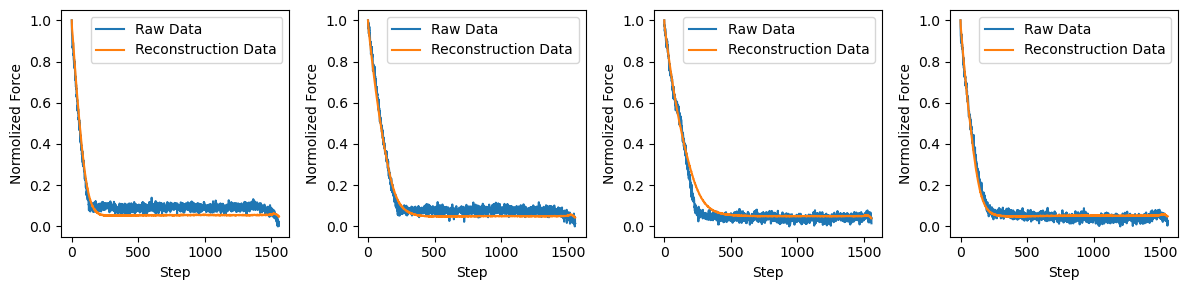

In [26]:
# put the model under eval mode
best_model.eval()

# collect the decoding curves and encoding latent space in the test dataset
with torch.no_grad():
    for indx, batch in enumerate(test_dataloader):
        x, y = batch
        y_hat, mu, logvar, _ = best_model(x)
        if indx == 0:
            y_list = y
            y_hat_list = y_hat
            mu_list = mu
            log_var_list = logvar
        else:
            y_list = torch.vstack([y_list,y])
            y_hat_list = torch.vstack([y_hat_list,y_hat])
            mu_list = torch.vstack([mu_list,mu])
            log_var_list = torch.vstack([log_var_list,logvar])

# plot the comparison between the reconstruction and the originals
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_apporach_plot_raw = y_list[idx].numpy()
    ax.plot(data_apporach_plot_raw[::-1], label="Raw Data")
    data_apporach_plot_reconstruct = y_hat_list[idx].numpy()
    ax.plot(data_apporach_plot_reconstruct[::-1], label="Reconstruction Data")    
    ax.set_xlabel("Step", fontsize=10)
    ax.set_ylabel("Normolized Force", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.legend()
fig.tight_layout()
plt.show()

### 2.6. Check the Latent Space 

Collect the decoding curves and encoding latent space in all curves ...

In [27]:
# Construct the 
all_dataloader = dl.DataLoader(
    AFMDataset(data=normolized_downsampling_data),
    batch_size=10240,
)

# collect the decoding curves and encoding latent space in the test dataset
with torch.no_grad():
    for indx, batch in enumerate(all_dataloader):
        x, y = batch
        y_hat, mu, logvar, _ = best_model(x)
        if indx == 0:
            x_list = x
            y_list = y
            y_hat_list = y_hat
            mu_list = mu
            log_var_list = logvar
        else:
            x_list = torch.vstack([x_list,x])
            y_list = torch.vstack([y_list,y])
            y_hat_list = torch.vstack([y_hat_list,y_hat])
            mu_list = torch.vstack([mu_list,mu])
            log_var_list = torch.vstack([log_var_list,logvar])

# Transfer them into Numpy array
x_list = x_list.numpy()
y_list = y_list.numpy()
y_hat_list = y_hat_list.numpy()
mu_list = mu_list.numpy()
log_var_list = log_var_list.numpy()

... and check the good/bad curves in the latent space generated by TSNE with the provided label ...

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(log_var_list)
tsne = TSNE(n_components=2) 
l2_X_tsne = tsne.fit_transform(X_std)

plt.scatter(l2_X_tsne[:,0],l2_X_tsne[:,1], c=label_set)
plt.colorbar()

... and play with weight.

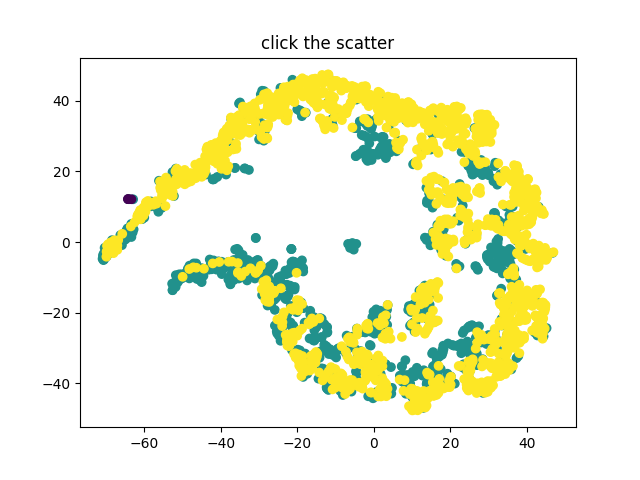

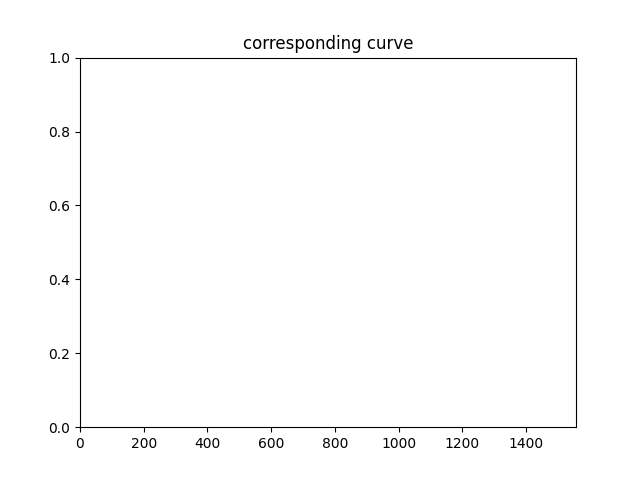

In [23]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

x = l2_X_tsne[:,0]
y = l2_X_tsne[:,1]
curves = x_list
x_curve = np.linspace(0, curves.shape[1], curves.shape[1])

fig_scatter, ax_scatter = plt.subplots()
sc = ax_scatter.scatter(x, y, c=label_set ,picker=True)
ax_scatter.set_title("click the scatter")

fig_scatter.canvas.toolbar_visible = True
fig_scatter.canvas.header_visible = False
fig_scatter.canvas.footer_visible = False

fig_curve, ax_curve = plt.subplots()
line, = ax_curve.plot([], [])
ax_curve.set_xlim(x_curve.min(), x_curve.max()) 
ax_curve.set_ylim(0, 1)
ax_curve.set_title("corresponding curve")


def on_click(event):
    if event.inaxes != ax_scatter:
        return
    
    distances = np.sqrt((x - event.xdata)**2 + (y - event.ydata)**2)
    idx = np.argmin(distances)

    line.set_data(x_curve, curves[idx])
    ax_curve.set_title(f"curve {idx}")
    fig_curve.canvas.draw_idle()


fig_scatter.canvas.mpl_connect('button_press_event', on_click)

ui = widgets.HBox([
    fig_scatter.canvas,
    fig_curve.canvas
])

display(ui)